# Web Python Programming Project 1  

## 1. Project Title

# 책을 많이 빌리는 동네는 술을 덜 마실까?  
### 서울 자치구 25곳, 가설을 따르는 동네와 비껴가는 동네

## 2. Why did you choose this topic?

친구가 "독서 바"라는 곳에 가봤다는 얘기를 한 적이 있다. 그 전까지 나는 술과 책이 서로 다른 영역에 있는 것이라고 생각했기 때문에 그 조합이 의외였다. 그러다 거꾸로 "그럼 책을 많이 읽는 사람은 정말 술을 덜 마실까?"라는 질문이 떠올랐다.

개인별 독서량과 음주량 자료를 직접 구하기는 어렵기 때문에, 본 프로젝트에서는 서울시 자치구별 공공도서관 이용 자료와 고위험 음주율 자료를 활용한다. 도서관 대출책수와 방문자수는 지역의 독서 및 문화 활동을 보여주는 간접 지표로, 고위험 음주율은 지역 주민의 음주 행태를 보여주는 건강 지표로 볼 수 있다.

단순히 대출책수 총합만 비교하면 인구가 많은 자치구가 유리할 수 있다. 그래서 본 분석에서는 인구수를 고려한 `인구 1만 명당 대출책수`와 `인구 1만 명당 방문자수`를 중심으로 분석한다.

## 3. Data Source and Data Description


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

# 한글 폰트 깨짐 방지
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Linux":
    plt.rc("font", family="NanumGothic")

plt.rcParams["axes.unicode_minus"] = False

library_file = "공공도서관_2023.xlsx"
population_file = "주민등록인구_2023.xlsx"
drinking_file = "고위험음주율_2023.xlsx"


### 3-1. Data Source Link

#### 서울시 고위험 음주율 통계 
https://data.seoul.go.kr/dataList/10673/S/2/datasetView.do
26.05.07
고위험음주율_2023.xlsx

#### 서울시 공공도서관 통계
https://data.seoul.go.kr/dataList/388/S/2/datasetView.do
26.05.07
공공도서관_2023.xlsx

#### 서울시 주민등록인구(내국인 각 세별/구별)(2014년 이후) 통계
https://data.seoul.go.kr/dataList/10719/S/2/datasetView.do
26.05.11
주민등록인구_2023.xlsx

### 3-2. Data Description

본 프로젝트에서는 2023년 서울시 25개 자치구 데이터를 사용하였다. 사용한 데이터는 공공도서관 데이터, 주민등록인구 데이터, 고위험 음주율 데이터이다. 세 데이터는 모두 자치구명을 기준으로 합쳐서 하나의 분석 데이터로 만들었다.

공공도서관 데이터에는 자치구별 도서관 수, 방문자 수, 장서 수, 연간대출 책수 등이 들어 있다. 이 중 연간대출 책수는 해당 지역에서 책을 얼마나 많이 빌리는지를 보여주는 자료이다.

주민등록인구 데이터에는 자치구별 전체 인구가 들어 있다. 인구가 많은 지역은 당연히 대출책수와 방문자수도 많을 가능성이 있기 때문에, 인구 자료를 이용해서 `인구 1만 명당 대출책수`와 `인구 1만 명당 방문자수`를 계산하였다.

고위험 음주율 데이터에는 자치구별 고위험 음주율이 들어 있다. 이 자료를 통해 각 자치구의 음주 관련 생활습관을 비교할 수 있다.

이 데이터들은 “책을 많이 빌리는 동네는 술을 덜 마실까?”라는 질문을 확인하기에 적절하다. 도서관 대출과 방문 자료는 지역의 독서 활동을 보여주고, 고위험 음주율은 지역의 음주 행태를 보여주기 때문이다. 즉, 두 자료를 자치구별로 비교하면 독서 활동이 활발한 지역에서 음주율이 낮게 나타나는지 확인할 수 있다.

분석에 사용하는 주요 컬럼은 다음과 같다.

- `district`: 자치구명
- `library_count`: 자치구 내 공공도서관 개수
- `visitors`: 연간 공공도서관 방문자 수
- `loans`: 연간 공공도서관 대출 책 수
- `population`: 2023년 자치구별 주민등록인구(내국인)
- `high_risk_drinking`: 고위험 음주율(%) — 1회 평균 음주량이 남자 7잔, 여자 5잔 이상이면서 주 2회 이상 음주하는 사람의 비율
- `loans_per_10000`: 인구 1만 명당 대출 책 수
- `visitors_per_10000`: 인구 1만 명당 방문자 수
- `libraries_per_100k`: 인구 10만 명당 도서관 수

In [2]:
# 공공도서관 데이터
library_raw = pd.read_excel(library_file, sheet_name="데이터", header=None)

library = library_raw.iloc[4:, [1, 2, 7, 8]]
library.columns = ["district", "library_count", "visitors", "loans"]

library = library[library["district"] != "소계"]
library = library.dropna(subset=["district"])

library["library_count"] = pd.to_numeric(library["library_count"].astype(str).str.replace(",", ""))
library["visitors"] = pd.to_numeric(library["visitors"].astype(str).str.replace(",", ""))
library["loans"] = pd.to_numeric(library["loans"].astype(str).str.replace(",", ""))


# 주민등록인구 데이터
population_raw = pd.read_excel(population_file, sheet_name="데이터", header=None)

population = population_raw.iloc[2:]
population.columns = population_raw.iloc[1]

population = population.rename(columns={
    "자치구별(1)": "district",
    "성별(1)": "sex",
    "합계": "population"
})

population["district"] = population["district"].ffill()

population = population[
    (population["sex"] == "합계") &
    (population["district"] != "합계")
]

population["population"] = pd.to_numeric(population["population"].astype(str).str.replace(",", ""))
population = population[["district", "population"]]


# 고위험 음주율 데이터
drinking_raw = pd.read_excel(drinking_file, sheet_name="데이터", header=None)

drinking = drinking_raw.iloc[18:, [2, 3]]
drinking.columns = ["district", "high_risk_drinking"]

drinking = drinking.dropna(subset=["district"])
drinking = drinking[drinking["district"].astype(str).str.endswith("구")]
drinking["high_risk_drinking"] = pd.to_numeric(drinking["high_risk_drinking"])


# 데이터 합치기
df = pd.merge(library, population, on="district")
df = pd.merge(df, drinking, on="district")

# 인구를 고려한 값 만들기
df["loans_per_10000"] = df["loans"] / df["population"] * 10000
df["visitors_per_10000"] = df["visitors"] / df["population"] * 10000
df["libraries_per_100k"] = df["library_count"] / df["population"] * 100000
df["loans_per_visitor"] = df["loans"] / df["visitors"]

display(df.head())

/home/emjdp/miniconda3/envs/jupyter/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/emjdp/miniconda3/envs/jupyter/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/emjdp/miniconda3/envs/jupyter/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,district,library_count,visitors,loans,population,high_risk_drinking,loans_per_10000,visitors_per_10000,libraries_per_100k,loans_per_visitor
0,종로구,9,2516259,787169,139417,10.7,56461.478873,180484.374215,6.455454,0.312833
1,중구,9,1519574,711369,121312,7.6,58639.623450,125261.639409,7.418887,0.468137
2,용산구,4,1524927,587605,213151,10.9,27567.546012,71542.099263,1.876604,0.385333
3,성동구,7,1755554,860222,277361,9.1,31014.526195,63294.911685,2.523787,0.490000
4,광진구,7,2154122,1217825,335554,12.3,36292.966259,64195.986339,2.086102,0.565346


In [3]:
# 분석에 사용할 주요 변수 확인
analysis_cols = [
    "district",
    "population",
    "library_count",
    "visitors",
    "loans",
    "loans_per_10000",
    "visitors_per_10000",
    "libraries_per_100k",
    "high_risk_drinking"
]

display(df[analysis_cols].sort_values("loans_per_10000", ascending=False))
display(df[analysis_cols[1:]].describe())


,district,population,library_count,visitors,loans,loans_per_10000,visitors_per_10000,libraries_per_100k,high_risk_drinking
1,중구,121312,9,1519574,711369,58639.623450,125261.639409,7.418887,7.6
0,종로구,139417,9,2516259,787169,56461.478873,180484.374215,6.455454,10.7
22,강남구,544873,16,4143366,2272229,41701.992941,76042.784282,2.936464,8.3
24,강동구,459167,9,3309953,1786397,38905.169579,72086.038413,1.960071,9.7
13,마포구,363697,6,2537829,1378450,37901.054999,69778.661908,1.649725,7.5
4,광진구,335554,7,2154122,1217825,36292.966259,64195.986339,2.086102,12.3
14,양천구,436028,10,2442236,1502572,34460.447494,56010.990120,2.293431,9.5
21,서초구,407664,9,1973869,1309817,32129.817693,48419.016641,2.207700,6.8
3,성동구,277361,7,1755554,860222,31014.526195,63294.911685,2.523787,9.1
2,용산구,213151,4,1524927,587605,27567.546012,71542.099263,1.876604,10.9


,population,library_count,visitors,loans,loans_per_10000,visitors_per_10000,libraries_per_100k,high_risk_drinking
count,25.000000,25.000000,2.500000e+01,2.500000e+01,25.000000,25.000000,25.000000,25.000000
mean,375441.360000,8.280000,1.901528e+06,1.016503e+06,28502.943042,55844.580076,2.474081,10.264000
std,127325.875641,3.007214,8.981706e+05,4.574405e+05,11691.018724,34864.425061,1.468344,1.822288
min,121312.000000,4.000000,4.827100e+05,4.073530e+05,9544.253002,10144.287030,1.037439,6.800000
25%,306231.000000,6.000000,1.380104e+06,7.394780e+05,20348.863681,33634.403561,1.713906,9.500000
50%,378769.000000,9.000000,1.755554e+06,9.230540e+05,26005.137696,48419.016641,2.086102,10.100000
75%,459167.000000,9.000000,2.442236e+06,1.217825e+06,34460.447494,64195.986339,2.638143,11.100000
max,654166.000000,16.000000,4.143366e+06,2.272229e+06,58639.623450,180484.374215,7.418887,15.600000


## 4. Hypothesis and Analysis


# 4-1. Hypothesis 1

**인구 1만 명당 공공도서관 대출책수가 많은 자치구일수록 고위험 음주율은 낮을 것이다.**

## A. Why is this hypothesis meaningful?

이 가설은 프로젝트 제목인 “책을 많이 빌리는 동네는 술을 덜 마실까?”와 직접적으로 연결된다. 단순 대출책수는 인구가 많은 지역일수록 커질 수 있으므로, 자치구별 인구수를 고려한 `loans_per_10000`을 사용하였다.

## B. Columns used

- `district`: 자치구
- `loans`: 연간대출 책수
- `population`: 주민등록인구
- `loans_per_10000`: 인구 1만 명당 대출책수
- `high_risk_drinking`: 고위험 음주율

## C. Graph used

산점도와 추세선을 사용하여 두 변수 사이의 관계를 확인하고, 상관계수를 계산하여 관계의 방향과 강도를 확인한다.


In [4]:
# 인구 1만 명당 대출책수와 고위험 음주율의 상관관계
corr1 = df["loans_per_10000"].corr(df["high_risk_drinking"])

print("상관계수:", round(corr1, 3))

상관계수: -0.41


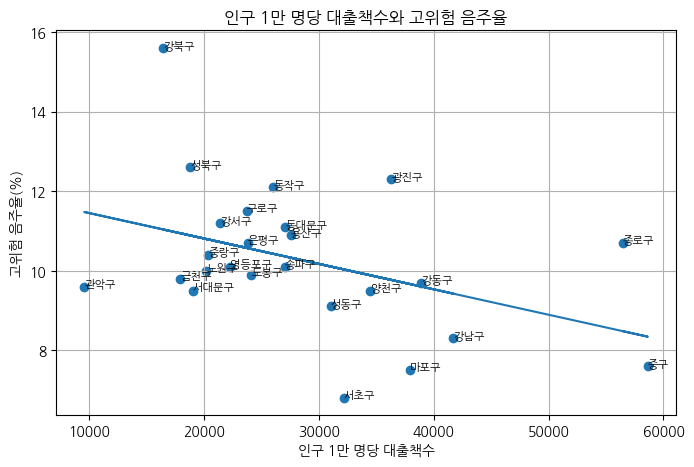

In [5]:
# 산점도로 확인
plt.figure(figsize=(8, 5))

plt.scatter(df["loans_per_10000"], df["high_risk_drinking"])

x = df["loans_per_10000"]
y = df["high_risk_drinking"]
a, b = np.polyfit(x, y, 1)
plt.plot(x, a * x + b)

for i in range(len(df)):
    plt.text(df["loans_per_10000"].iloc[i], df["high_risk_drinking"].iloc[i], df["district"].iloc[i], fontsize=8)

plt.title("인구 1만 명당 대출책수와 고위험 음주율")
plt.xlabel("인구 1만 명당 대출책수")
plt.ylabel("고위험 음주율(%)")
plt.grid()

plt.show()


In [6]:
# 대출책수를 기준으로 상위/하위 그룹 나누기
median_loan = df["loans_per_10000"].median()
print("중앙값:", median_loan)

loan_group = []

for value in df["loans_per_10000"]:
    if value >= median_loan:
        loan_group.append("대출 많음")
    else:
        loan_group.append("대출 적음")

df["loan_group"] = loan_group

group1 = df.groupby("loan_group")["high_risk_drinking"].mean()
group1

중앙값: 26005.13769606277


loan_group
대출 많음     9.669231
대출 적음    10.908333
Name: high_risk_drinking, dtype: float64

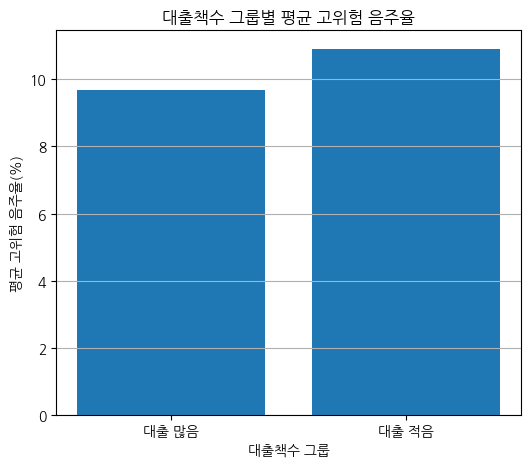

In [7]:
# 상위/하위 그룹의 평균 고위험 음주율 비교
plt.figure(figsize=(6, 5))

plt.bar(group1.index, group1.values)

plt.title("대출책수 그룹별 평균 고위험 음주율")
plt.xlabel("대출책수 그룹")
plt.ylabel("평균 고위험 음주율(%)")
plt.grid(axis="y")

plt.show()


## D. Result Interpretation

그래프를 보면 인구 1만 명당 대출책수가 높은 지역일수록 고위험 음주율이 조금 낮아지는 모습이 보인다. 상관계수도 음수로 나와서, 두 변수는 약한 음의 관계가 있다고 해석할 수 있다.

가설과 가장 잘 맞는 사례는 **중구**(대출 1위, 음주율 7.6%)와 **강북구**(대출 하위권, 음주율 15.6%로 25개 자치구 중 최고)이다. 분포의 양 끝이 가설 방향과 일치한다. 다만 **종로구**는 대출 2위인데 음주율은 평균(10.26%)을 살짝 웃돈다. 도심이라 주간 유동인구가 많은 영향일 수 있다.

따라서 가설은 어느 정도 맞는 방향으로 나타났지만, 모든 자치구에 똑같이 적용되지는 않는다.

# 4-2. Hypothesis 2

**인구 1만 명당 공공도서관 방문자 수가 많은 자치구일수록 고위험 음주율은 낮을 것이다.**

## A. Why is this hypothesis meaningful?

가설 1은 책을 실제로 빌린 정도를 보았다. 가설 2는 도서관을 방문한 정도를 본다. 도서관 방문자 수가 많은 지역은 문화시설 이용이 더 활발한 지역일 수 있으므로, 고위험 음주율과 어떤 관계가 있는지 확인할 필요가 있다.

## B. Columns used

- `district`: 자치구
- `visitors`: 도서관 방문자 수
- `population`: 주민등록인구
- `visitors_per_10000`: 인구 1만 명당 방문자 수
- `high_risk_drinking`: 고위험 음주율

## C. Graph used

산점도와 추세선을 사용하여 `visitors_per_10000`과 `high_risk_drinking`의 관계를 확인한다.


In [8]:
# 인구 1만 명당 방문자수와 고위험 음주율의 상관관계
corr2 = df["visitors_per_10000"].corr(df["high_risk_drinking"])

print("상관계수:", round(corr2, 3))

상관계수: -0.288


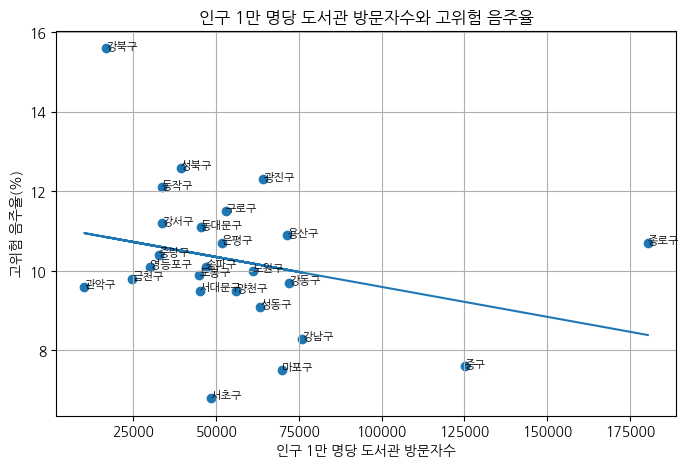

In [9]:
# 산점도로 확인
plt.figure(figsize=(8, 5))

plt.scatter(df["visitors_per_10000"], df["high_risk_drinking"])

x = df["visitors_per_10000"]
y = df["high_risk_drinking"]
a, b = np.polyfit(x, y, 1)
plt.plot(x, a * x + b)

for i in range(len(df)):
    plt.text(df["visitors_per_10000"].iloc[i], df["high_risk_drinking"].iloc[i], df["district"].iloc[i], fontsize=8)

plt.title("인구 1만 명당 도서관 방문자수와 고위험 음주율")
plt.xlabel("인구 1만 명당 도서관 방문자수")
plt.ylabel("고위험 음주율(%)")
plt.grid()

plt.show()


## D. Result Interpretation

인구 1만 명당 방문자수도 고위험 음주율과 음의 방향을 보였다. 다만 상관계수는 −0.29로, 가설 1의 대출책수(−0.41)보다 관계가 약했다.

도서관 방문에는 학습실 이용이나 시설 이용처럼 독서 외 목적도 섞일 수 있다. 그래서 단순 방문보다 실제 책을 빌린 정도가 고위험 음주율과 더 뚜렷하게 연결된다고 볼 수 있다.

# 4-3. Hypothesis 3

**단순 도서관 수보다 실제 이용 지표인 대출책수와 방문자수가 고위험 음주율과 더 관련이 있을 것이다.**

## A. Why is this hypothesis meaningful?

도서관이 많다는 것은 시설이 많다는 뜻이다. 하지만 시설이 많다고 해서 사람들이 실제로 많이 이용한다고 볼 수는 없다. 그래서 도서관 수, 대출책수, 방문자수를 함께 비교하여 어떤 지표가 고위험 음주율과 더 관련이 있는지 확인한다.

## B. Columns used

- `loans_per_10000`: 인구 1만 명당 대출책수
- `visitors_per_10000`: 인구 1만 명당 방문자 수
- `libraries_per_100k`: 인구 10만 명당 도서관 수
- `high_risk_drinking`: 고위험 음주율

## C. Graph used

도서관 관련 지표별 상관계수를 막대그래프로 비교한다. 추가로 평균값을 기준으로 사분면 그래프를 만들어 어떤 자치구가 가설과 잘 맞는지 확인한다.


In [10]:
# 도서관 관련 지표별 상관계수 비교
corr_data = pd.DataFrame({
    "variable": ["인구 1만 명당 대출책수", "인구 1만 명당 방문자수", "인구 10만 명당 도서관 수"],
    "correlation": [
        df["loans_per_10000"].corr(df["high_risk_drinking"]),
        df["visitors_per_10000"].corr(df["high_risk_drinking"]),
        df["libraries_per_100k"].corr(df["high_risk_drinking"])
    ]
})

corr_data = corr_data.sort_values("correlation")

corr_data

,variable,correlation
0,인구 1만 명당 대출책수,-0.409808
1,인구 1만 명당 방문자수,-0.287792
2,인구 10만 명당 도서관 수,-0.111957


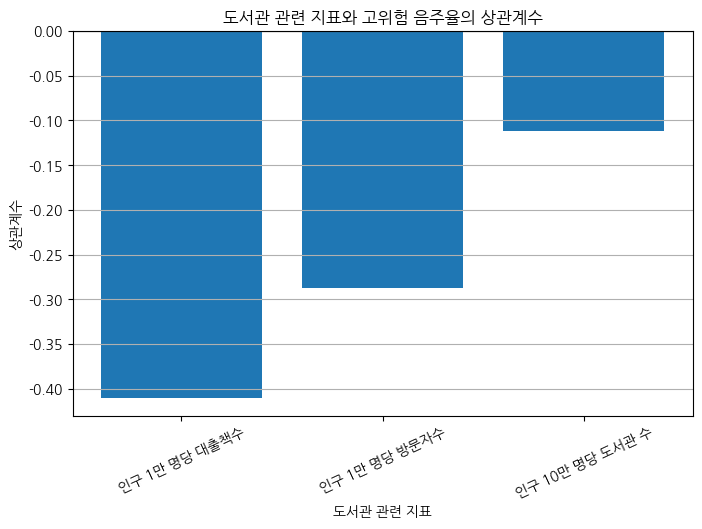

In [11]:
# 상관계수 막대그래프
plt.figure(figsize=(8, 5))

plt.bar(corr_data["variable"], corr_data["correlation"])
plt.axhline(0, color="black")

plt.title("도서관 관련 지표와 고위험 음주율의 상관계수")
plt.xlabel("도서관 관련 지표")
plt.ylabel("상관계수")
plt.xticks(rotation=25)
plt.grid(axis="y")

plt.show()


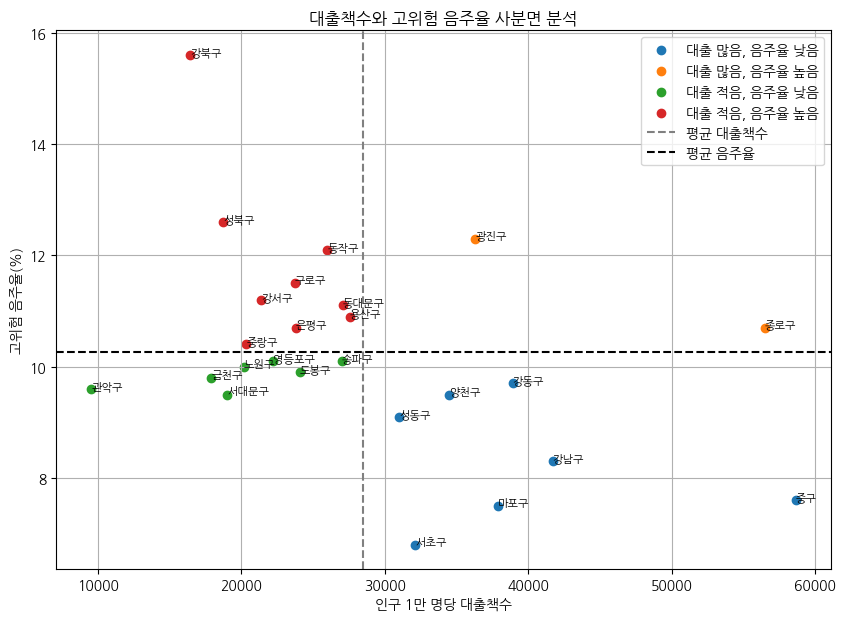

,district,loans_per_10000,high_risk_drinking,quadrant
24,강동구,38905.169579,9.7,"대출 많음, 음주율 낮음"
1,중구,58639.623450,7.6,"대출 많음, 음주율 낮음"
22,강남구,41701.992941,8.3,"대출 많음, 음주율 낮음"
3,성동구,31014.526195,9.1,"대출 많음, 음주율 낮음"
21,서초구,32129.817693,6.8,"대출 많음, 음주율 낮음"
14,양천구,34460.447494,9.5,"대출 많음, 음주율 낮음"
13,마포구,37901.054999,7.5,"대출 많음, 음주율 낮음"
0,종로구,56461.478873,10.7,"대출 많음, 음주율 높음"
4,광진구,36292.966259,12.3,"대출 많음, 음주율 높음"
12,서대문구,19004.607633,9.5,"대출 적음, 음주율 낮음"


In [12]:
# 사분면 분석
loan_mean = df["loans_per_10000"].mean()
drink_mean = df["high_risk_drinking"].mean()

quadrant = []

for i in range(len(df)):
    loan = df["loans_per_10000"].iloc[i]
    drink = df["high_risk_drinking"].iloc[i]

    if loan >= loan_mean and drink < drink_mean:
        quadrant.append("대출 많음, 음주율 낮음")
    elif loan < loan_mean and drink >= drink_mean:
        quadrant.append("대출 적음, 음주율 높음")
    elif loan >= loan_mean and drink >= drink_mean:
        quadrant.append("대출 많음, 음주율 높음")
    else:
        quadrant.append("대출 적음, 음주율 낮음")

df["quadrant"] = quadrant

plt.figure(figsize=(10, 7))

for label, group in df.groupby("quadrant"):
    plt.scatter(group["loans_per_10000"], group["high_risk_drinking"], label=label)

plt.axvline(loan_mean, color="gray", linestyle="--", label="평균 대출책수")
plt.axhline(drink_mean, color="black", linestyle="--", label="평균 음주율")

for i in range(len(df)):
    plt.text(df["loans_per_10000"].iloc[i], df["high_risk_drinking"].iloc[i], df["district"].iloc[i], fontsize=8)

plt.title("대출책수와 고위험 음주율 사분면 분석")
plt.xlabel("인구 1만 명당 대출책수")
plt.ylabel("고위험 음주율(%)")
plt.grid()
plt.legend()
plt.show()

display(df[["district", "loans_per_10000", "high_risk_drinking", "quadrant"]].sort_values("quadrant"))

## D. Result Interpretation

세 지표를 비교한 결과, 단순히 도서관이 몇 개 있는지보다 실제 이용량에 가까운 대출책수와 방문자수가 고위험 음주율과 더 관련이 있었다. 인구 10만 명당 도서관 수의 상관계수가 가장 약했는데, 시설이 많다는 사실만으로는 지역의 독서 활동을 설명하기 어렵다는 뜻이다.

사분면 그래프에서 가설과 잘 맞는 자치구는 **중구·강남구**(대출 많고 음주율 낮음)와 **강북구**(대출 적고 음주율 높음)이다. 반대로 **관악구**는 대출이 가장 적은데도 음주율은 평균 이하라서 가설에서 벗어났다. 1인 가구·청년층이 많은 지역 특성과 관련 있을 수 있다.

즉 자치구 단위에서 평균적으로는 가설이 지지되지만, 자치구의 성격에 따라 다르게 나타난다.

# 5. Final Conclusion

이번 프로젝트에서는 "책을 많이 빌리는 동네는 술을 덜 마실까?"라는 질문을 가지고 서울시 25개 자치구 데이터를 분석하였다. 분석에는 공공도서관 대출 및 방문 자료, 주민등록인구 자료, 고위험 음주율 자료를 사용하였다.

첫 번째 가설에서는 인구 1만 명당 대출책수가 높은 지역일수록 고위험 음주율이 낮은지 확인하였다. 분석 결과 두 변수는 음의 상관관계를 보였고, 책을 많이 빌리는 지역일수록 고위험 음주율이 낮아지는 경향이 어느 정도 나타났다. 따라서 첫 번째 가설은 어느 정도 지지된다고 볼 수 있다.

두 번째 가설에서는 인구 1만 명당 도서관 방문자수가 많은 지역일수록 고위험 음주율이 낮은지 확인하였다. 방문자수 역시 고위험 음주율과 반대 방향의 관계를 보였지만, 대출책수보다는 약한 관계로 나타났다.

세 번째 가설에서는 단순 도서관 수보다 실제 이용 지표인 대출책수와 방문자수가 고위험 음주율과 더 관련이 있는지 확인하였다. 분석 결과 도서관 수보다 이용 지표가 더 의미 있는 비교 기준이 될 수 있었다.

결론적으로 서울시 자치구 단위에서는 책을 많이 빌리는 지역일수록 고위험 음주율이 낮은 경향이 있었다. 다만 이번 분석에서 가장 인상적이었던 점은 가설이 잘 맞는 자치구와 그렇지 않은 자치구가 지역의 성격에 따라 갈렸다는 것이다. 주거 중심 자치구에서는 도식이 비교적 잘 맞았지만, 도심형 자치구(종로·중구)나 1인 가구가 많은 관악구에서는 같은 도식이 흔들렸다.

물론 자치구 집계자료를 사용한 분석이기 때문에 개인별로 단정할 수는 없고, 소득·교육·연령구조 같은 다른 요인들도 영향을 줄 수 있다.

분석을 마치고 보니, 처음에 의외라고 생각했던 친구의 "독서 바" 얘기가 그렇게 이상한 조합만은 아니었다는 생각이 든다. 책과 술이 무조건 반대 영역에 있는 것도 아니고, 동네마다 사람들의 생활은 한 줄 가설로 정리하기에 생각보다 복잡하다는 걸 이번 분석에서도 어느 정도 볼 수 있었다

# 6. References

- 서울 열린데이터광장, 「서울시 공공도서관 통계」, 2023.  
  원자료: 문화체육관광부 국가도서관통계시스템  
  https://data.seoul.go.kr/dataList/388/S/2/datasetView.do

- 서울 열린데이터광장, 「서울시 주민등록인구(내국인 각 세별/구별)(2014년 이후) 통계」, 2023. 
  https://data.seoul.go.kr/dataList/10719/S/2/datasetView.do

- 서울 열린데이터광장, 「서울시 고위험 음주율 통계」, 2023.  
  원자료: 서울의료원 공공보건의료지원단 / 지역사회 건강조사 등을 활용한 가공통계 
  https://data.seoul.go.kr/dataList/10673/S/2/datasetView.do